In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from corner import corner
from matplotlib.ticker import MultipleLocator

In [15]:
## -- Test 1 (Masked Fits)
# uniform-limb spectrum
waves, wavehws, s1_depths, s1_deptherrs = np.loadtxt('./data/spectra/V1298Tauc_SOSS_LCtest1_R50.txt', unpack=True, skiprows=2)
# timing biases
void, void, s1_dt, s1_dterr = np.loadtxt('./data/spectra/V1298Tauc_SOSS_LCtest1_dtspectrum_R50.txt', unpack=True, skiprows=1)
# evening-limb spectrum
void, void, s1_edepths, s1_edeptherrs = np.loadtxt('./data/spectra/V1298Tauc_SOSS_LCtest1_eveninglimb_R50.txt', unpack=True, skiprows=1)
# morning-limb spectrum
void, void, s1_mdepths, s1_mdeptherrs = np.loadtxt('./data/spectra/V1298Tauc_SOSS_LCtest1_morninglimb_R50.txt', unpack=True, skiprows=1)

## -- Test 2 (Gaussian)
# uniform-limb spectrum
void, void, s2_depths, s2_deptherrs = np.loadtxt('./data/spectra/V1298Tauc_SOSS_LCtest2_6spots_R50.txt', unpack=True, skiprows=2)
# timing biases
void, void, s2_dt, s2_dterr = np.loadtxt('./data/spectra/V1298Tauc_SOSS_LCtest2_dtspectrum_R50.txt', unpack=True, skiprows=1)
# evening-limb spectrum
void, void, s2_edepths, s2_edeptherrs = np.loadtxt('./data/spectra/V1298Tauc_SOSS_LCtest2_eveninglimb_R50.txt', unpack=True, skiprows=1)
# morning-limb spectrum
void, void, s2_mdepths, s2_mdeptherrs = np.loadtxt('./data/spectra/V1298Tauc_SOSS_LCtest2_morninglimb_R50.txt', unpack=True, skiprows=1)


In [16]:
## -- colors:
c1 = '#0652FF'
fc1 = '#316BEC'

c2 = 'green'
fc2 = '#13AF13'

In [17]:
def calc_1H_depth(H, Rp, Rstar):
    """ Calculates the increase in transit depth corresponding to one scale height increase in radius
    Follows Stevenson 2016:
        delta ~ (2 * H * Rp)/(Rs^2)
    H = scale height in [km]
    Rp = planet radius in [R jupiter]
    Rstar = stellar radius in [R sun]
    """
    # constants:
    Rjupiter = 69911000.0 # [m]; approx. radius of Jupiter
    Rsun = 6.957e8 # [m]; radius of the sun

    # convert to physical units
    H_meter = H*1000. # [m]
    Rp_meter = Rp * Rjupiter
    Rstar_meter = Rstar * Rsun

    # calculate
    d = (2.*H_meter*Rp_meter)/(Rstar_meter**2)
    return d

In [18]:
## -- planet and star properties
Rsun = 6.955e10 #cm
Rstar = 1.292*Rsun #Rsun

Mearth = 5.974e27 # g
Rearth = 6.378e8 #cm
Rjupiter = 7.149e9 #cm
Mp = 4.7*Mearth # Mearth
Rp = 5.08*Rearth # Rearth
Teq = 953 # K
mu = 2.3
mH = 1.6605e-24 #g
kB = 1.3807e-16 # (cm^2 g /s^2 / K)
G = 6.6743e-8 # cm^3/g/s^2
g = (G*Mp)/(Rp**2)

Rpe = np.sqrt((2.*s2_edepths)/1.e6)*Rstar #cm
Rpm = np.sqrt((2.*s2_mdepths)/1.e6)*Rstar #cm
Rpeff = np.median(np.sqrt(0.5*(Rpe**2 + Rpm**2)))

## -- compute scale height
H_cm = (kB*Teq)/(mu*mH*g) # assuming mu=2.3
H_km = H_cm / (100000)

## -- convert observed dt to dN
temp = 0.00496*H_km - 0.13
dt_s = s2_dt * 60.
dN = dt_s / temp

## -- E-M depth difference
ddepth = (2*s2_edepths/1.e6) - (2*s2_mdepths/1.e6)
ddeptherr = np.sqrt((2.*s2_edeptherrs/1.e6)**2 + (2.*s2_mdeptherrs/1.e6)**2)

ddepth_1H = calc_1H_depth(H_km, (Rp/Rjupiter), (Rstar/Rsun))

# Murphy et al. 2024 prediction:
dN_obs = ddepth / ddepth_1H
dt_s_pred = dN_obs*(0.00496*H_km - 0.13) 

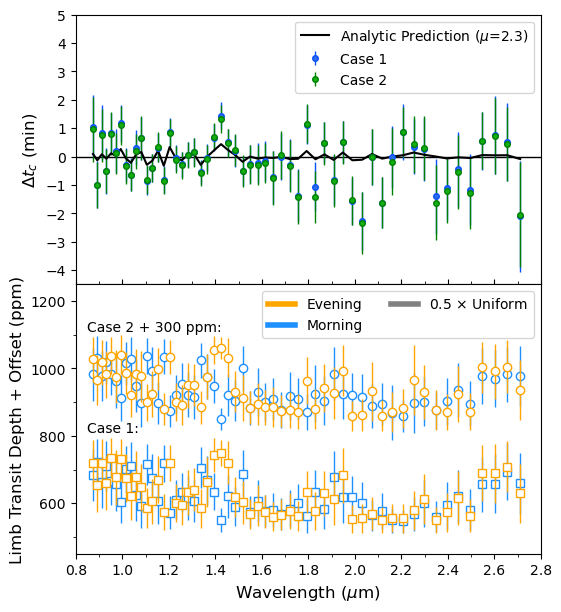

In [19]:
## -- paper plot:
fig, ax = plt.subplots(figsize=(6,7), nrows=2, sharex=True)
plt.subplots_adjust(hspace=0)
# TC
ax[0].axhline(0., c='black', lw=1)
ax[0].errorbar(waves, s1_dt, s1_dterr, ls='None', marker='o', ms=4, lw=1, c=c1, mec=c1, mfc=fc1, label='Case 1')
ax[0].errorbar(waves, s2_dt, s2_dterr, ls='None', marker='o', ms=4, lw=1, c=c2, mec=c2, mfc=fc2, label='Case 2')
ax[0].plot(waves, dt_s_pred/60., c='black', label=r'Analytic Prediction ($\mu$=2.3)')
ax[0].set_ylabel(r'$\Delta t_c$ (min)', fontsize=12)
ax[0].set_ylim(-4.5,5)
ax[0].yaxis.set_major_locator(MultipleLocator(1))
ax[0].legend(loc='upper right')
ax[0].tick_params(axis='x', which='both', direction='in')

# SPEC
ax[1].errorbar(waves, s1_edepths, s1_edeptherrs, ls='None', marker='s', ms=6, lw=1, zorder=2, c='orange', mec='orange', mfc='white', alpha=1)
ax[1].errorbar(waves, s1_mdepths, s1_mdeptherrs, ls='None', marker='s', ms=6, lw=1, zorder=1, c='dodgerblue', mec='dodgerblue', mfc='white', alpha=1)
ax[1].errorbar(waves, 0.5*s1_depths, 0.5*s1_deptherrs, ls='None', marker='s', ms=6, lw=1, zorder=5, c='black', mec='black', mfc='gray')
ax[1].text(0.85, 810, 'Case 1:', fontsize=10, c='black')

ax[1].errorbar(waves, s2_edepths + 300, s2_edeptherrs, ls='None', marker='o', ms=6, lw=1, zorder=2, c='orange', mec='orange', mfc='white')
ax[1].errorbar(waves, s2_mdepths + 300, s2_mdeptherrs, ls='None', marker='o', ms=6, lw=1, zorder=1, c='dodgerblue', mec='dodgerblue', mfc='white')
ax[1].errorbar(waves, 0.5*s2_depths + 300, 0.5*s2_deptherrs, ls='None', marker='o', ms=6, lw=1, zorder=5, c='black', mec='black', mfc='gray')
ax[1].text(0.85, 1110, 'Case 2 + 300 ppm:', fontsize=10, c='black')
ax[1].set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
ax[1].set_ylabel(r'Limb Transit Depth + Offset (ppm)', fontsize=12)
ax[1].set_xlim(0.8, 2.8)
ax[1].set_ylim(450,1250)
ax[1].yaxis.set_major_locator(MultipleLocator(200))
ax[1].yaxis.set_minor_locator(MultipleLocator(100))
ax[1].xaxis.set_major_locator(MultipleLocator(0.2))
ax[1].xaxis.set_minor_locator(MultipleLocator(0.1))

ax[1].plot([0],[0], c='orange', lw=4, label='Evening')
ax[1].plot([0],[0], c='dodgerblue', lw=4, label='Morning')
ax[1].plot([0],[0], c='gray', lw=4, label=r'0.5 $\times$ Uniform')
ax[1].legend(loc='upper right', ncol=2)
plt.savefig('./figures/Figure8.png', dpi=600, bbox_inches='tight')
plt.show()